In [1]:
from pathlib import Path
import geopandas as gpd 
import matplotlib.pyplot as plt 

In [2]:
current_directory = Path.cwd()

In [3]:
#Define of project paths 

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

raw_data_directory = project_root/"data"/"raw"
processed_data_directory = project_root/"data"/"processed"
figures_directory = project_root/"ouputs"/"figures"
   

In [4]:
#Loading spatial data

boundary_file =(raw_data_directory/"greater_accra_boundary.geojson")
station_file = (processed_data_directory/"verified_swap_station_points.geojson")

study_boundary = gpd.read_file(boundary_file)
station_gdf = gpd.read_file(station_file)

In [5]:
#estimating suitbale metre-based crs(coordinate refernce system )
metric_crs = study_boundary.estimate_utm_crs()

print(metric_crs)

EPSG:32631


In [6]:
#Projecting datasets metre

study_boundary_projected = (study_boundary.to_crs(metric_crs))
stations_projected = (station_gdf.to_crs(metric_crs))

In [7]:
print(study_boundary_projected)
print(stations_projected)

   bbox_west  bbox_south  bbox_east  bbox_north  place_id  osm_type   osm_id  \
0  -0.519705    5.470652   0.672259    6.107615  40402087  relation  1991849   

        lat       lon     class            type  place_rank  importance  \
0  5.810153  0.099524  boundary  administrative           8    0.500795   

  addresstype                  name                 display_name  \
0       state  Greater Accra Region  Greater Accra Region, Ghana   

                                            geometry  
0  POLYGON ((110026.821 631288.431, 110109.332 63...  
  analysis_id source_station_id station_area                landmark  \
0      PUB001       Station 002    Abelemkpe     Near Pan African TV   
1      PUB002       Station 003       Adenta            Housing Down   
2      PUB003       Station 004     Kaneshie           Near Vitamilk   
3      PUB004       Station 005   Kokomlemle         Opposite Auto Z   
4      PUB005       Station 006      Spintex        Adjacent Ecobank   
5      PU

In [8]:
#Validating if the datasets of the projected is equal
print("Are same:", stations_projected.crs == study_boundary_projected.crs)

Are same: True


In [9]:
#Checking differnence between projected and actual

print("Before Projection:")
print(station_gdf.geometry.head(3))

print("\n After Projection:")
print(stations_projected.geometry.head(3))

Before Projection:
0    POINT (-0.22053 5.61314)
1    POINT (-0.15099 5.70882)
2    POINT (-0.23944 5.57067)
Name: geometry, dtype: geometry

 After Projection:
0    POINT (143157.227 621422.112)
1    POINT (150927.924 631972.819)
2    POINT (141033.083 616731.371)
Name: geometry, dtype: geometry


Create 3 km station buffers - Each station recives 3km /3,000 metre buffer representing the intial straight line coverage area .

In [10]:
coverage_radius_metre = 3_000

In [11]:
#creating buffer geodataframe

coverage_buffers = stations_projected.copy()
coverage_buffers['geometry'] = (stations_projected.geometry.buffer(coverage_radius_metre))

In [12]:
#calculating of buffer areas

coverage_buffers["buffer_area_km2"] = (coverage_buffers.geometry.area/ 1_000_000)

In [13]:
coverage_buffers[["station_area","buffer_area_km2"]]

,station_area,buffer_area_km2
0,Abelemkpe,28.228936
1,Adenta,28.228936
2,Kaneshie,28.228936
3,Kokomlemle,28.228936
4,Spintex,28.228936
5,Aviation,28.228936
6,Osu,28.228936
7,Haatso,28.228936


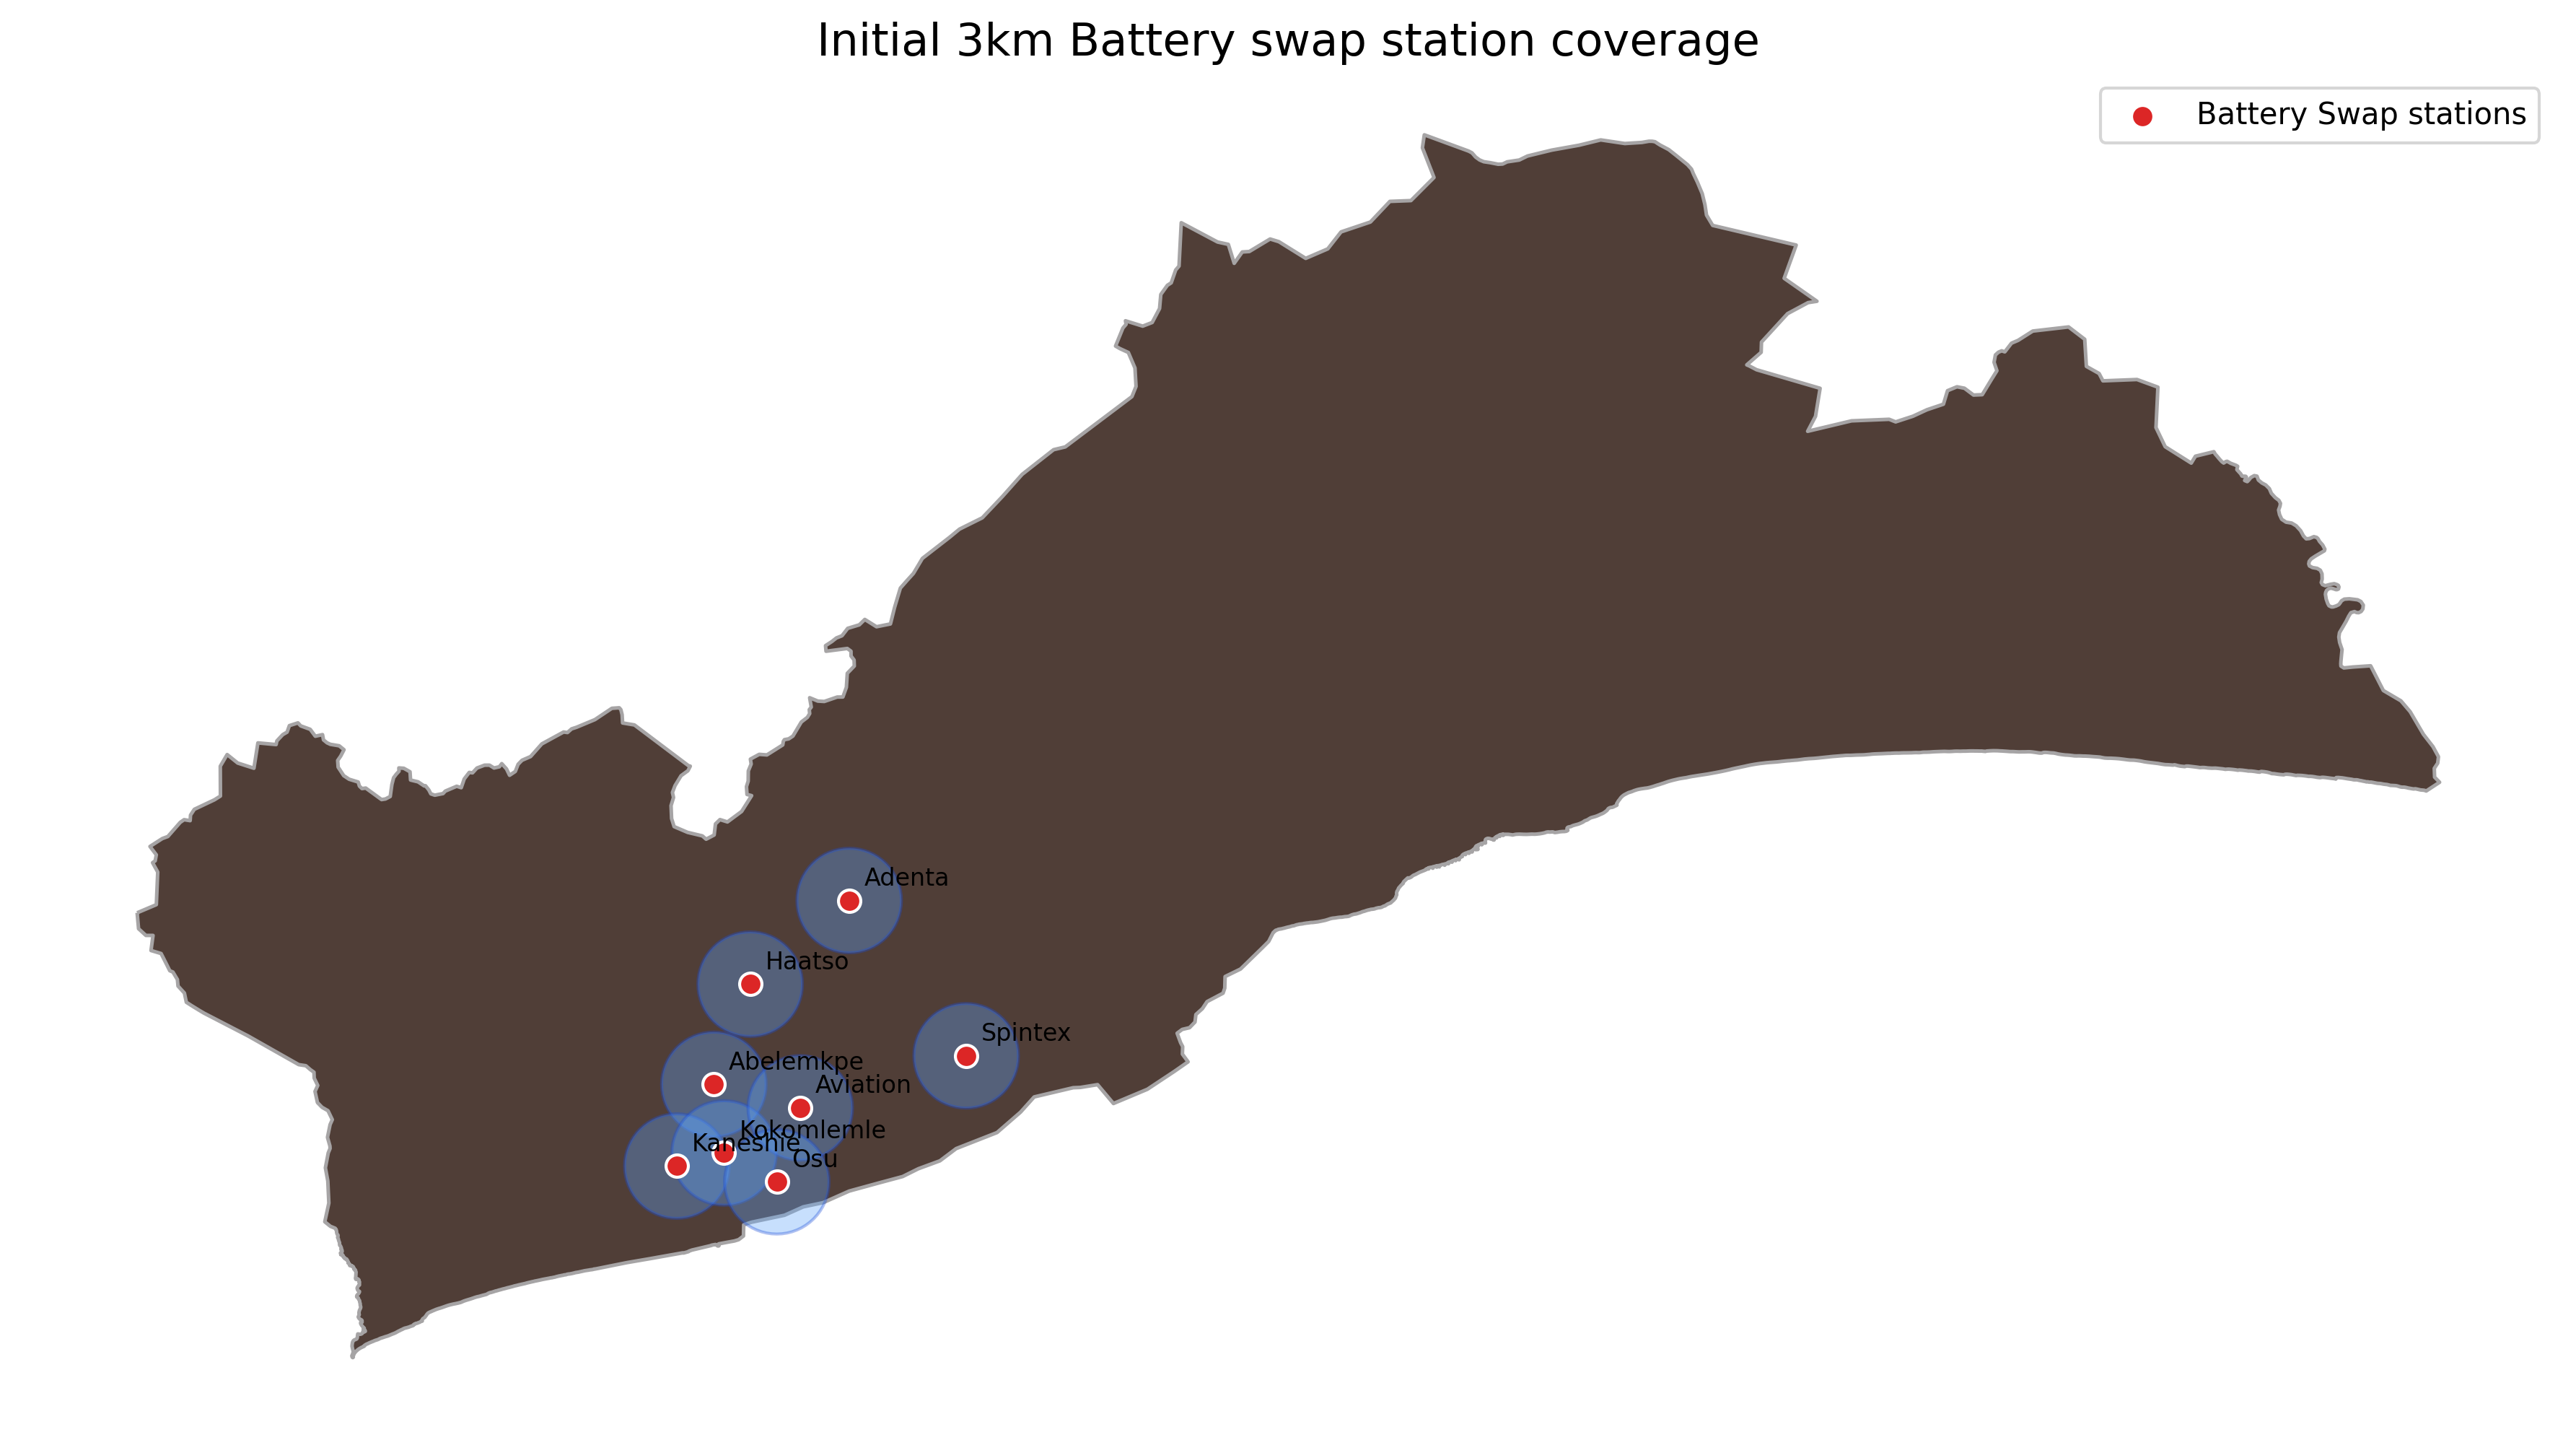

In [14]:
#Plotting of buffers coverage

fig,ax = plt.subplots(figsize=(12,10),dpi=300)
study_boundary_projected.plot( ax=ax,facecolor="#503E37",edgecolor="#a6a4a5",linewidth=1.2,zorder=1,)

coverage_buffers.plot(ax=ax,facecolor="#60a5fa",edgecolor="#1d4ed8",alpha=0.35,linewidth=1,zorder=2,)
stations_projected.plot(ax=ax,color="#dc2626",edgecolor="white",markersize=55,label="Battery Swap stations",zorder=3,)

for _,station in stations_projected.iterrows():
    ax.annotate(text=station["station_area"],xy=(station.geometry.x,station.geometry.y,),
                xytext=(5,5),textcoords="offset points",fontsize=8,zorder=4)
ax.set_title("Initial 3km Battery swap station coverage",fontsize=15,)
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [36]:
#Validting buffer centers aligns 
buffer_centers = (coverage_buffers.geometry.centroid)
centre_offset_metres = (buffer_centers.distance(stations_projected.geometry))
print(centre_offset_metres)

0    0.000000e+00
1    1.301563e-10
2    0.000000e+00
3    2.910383e-11
4    1.301563e-10
5    3.599945e-10
6    1.301563e-10
7    2.346426e-10
dtype: float64


Overlapping station buffers to be merged into a unique coverage footprint.

In [15]:
merged_coverage_geometry = (coverage_buffers.geometry.union_all())

print(merged_coverage_geometry.geom_type,)
print(merged_coverage_geometry.is_valid,)

MultiPolygon
True


In [37]:
merged_coverage = gpd.GeoDataFrame(
    {"coverage_type":["unique 3km coverage"]},geometry=[merged_coverage_geometry],crs=coverage_buffers.crs
)

In [40]:
#calculating seperate buffers
individual_area_km2 = (coverage_buffers.geometry.area.sum() / 1_000_000)

In [41]:
#calculate unique merged area
unique_coverage_area_km2 = (merged_coverage_geometry.area / 1_000_000)

In [42]:
#calculaing overlapp
overlapping_area_km2 = (individual_area_km2 - unique_coverage_area_km2)

In [49]:
print("Individula buffers:",round(individual_area_km2,2),"km2")
print("unique coverage:",round(unique_coverage_area_km2,2),"km2")
print("Overlapping area:",round(overlapping_area_km2,2),"km2")

Individula buffers: 225.83 km2
unique coverage: 191.67 km2
Overlapping area: 34.16 km2


Restricting Coverage boundary to region only within Area.

In [51]:
same_crs = merged_coverage.crs == study_boundary_projected.crs
same_crs

True

In [52]:
study_boundary_geometry = (study_boundary_projected.geometry.union_all())

In [53]:
print("boundary valid:",study_boundary_geometry.is_valid,)
print("Boundary empty:",study_boundary_geometry.is_empty,)

boundary valid: True
Boundary empty: False


In [55]:
#test spatial relationship
coverage_intersects_boundary = (merged_coverage_geometry.intersects(study_boundary_geometry))
coverage_intersects_boundary

True

In [ ]:
#remove shared area ,this merges coverage of greater Accra and its boundary
clipped_coverage_geometry = (merged_coverage_geometry.intersection(study_boundary_geometry))

In [57]:
print("Clipped geometry is valid:",clipped_coverage_geometry.is_valid,)
print("Clipped geometry empty:",clipped_coverage_geometry.is_empty,)

Clipped geometry is valid: True
Clipped geometry empty: False


In [58]:
#Creating a clipped GeoDataframe 
clipped_coverage = gpd.GeoDataFrame({"coverage_type":["unique coverage inside study area"],},
geometry=[clipped_coverage_geometry],crs=study_boundary_projected.crs,) 

In [59]:
#meaure what clipping removed

clipped_coverage_area_km2 = (clipped_coverage_geometry.area /1_000_000)
outside_boundary_area_km2 = (unique_coverage_area_km2 - clipped_coverage_area_km2)


print("Unique coverage before clipping:",round(unique_coverage_area_km2, 2),"km²",)
print("Coverage inside boundary:",round(clipped_coverage_area_km2, 2),"km²",)
print("Coverage removed:",round(outside_boundary_area_km2, 2),"km²",)


Unique coverage before clipping: 191.67 km²
Coverage inside boundary: 187.9 km²
Coverage removed: 3.76 km²


#calculating the uncovered area , which can represented by : uncovered area = study boundary - clipped coverage

In [60]:
uncovered_geometry = (study_boundary_geometry.difference(clipped_coverage_geometry))

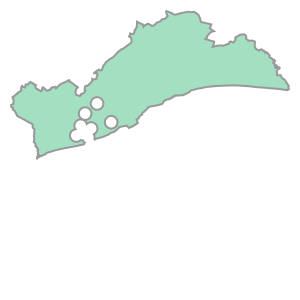

In [61]:
study_boundary_geometry.difference(clipped_coverage_geometry)

In [62]:
uncovered_area = gpd.GeoDataFrame({"coverage_status":["outside 3km coverage"],},
geometry=[uncovered_geometry],crs=study_boundary_projected.crs,)

In [63]:
#calculating Coverage metrics
total_study_area_km2 = (study_boundary_geometry.area / 1_000_000)
covered_area_km2 = (clipped_coverage_geometry.area / 1_000_000)
uncovered_area_km2 = (uncovered_geometry.area / 1_000_000)
covered_percentage = (covered_area_km2 / total_study_area_km2 * 100)
uncovered_percentage = (uncovered_area_km2 / total_study_area_km2 * 100)

In [64]:
print("Total study area:",round(total_study_area_km2, 2),"km²",)
print("Covered area:",round(covered_area_km2, 2),"km²",)
print("Uncovered area:",round(uncovered_area_km2, 2),"km²",)
print("Covered percentage:",round(covered_percentage, 2),"%",)
print("Uncovered percentage:",round(uncovered_percentage, 2),"%",)

Total study area: 3700.04 km²
Covered area: 187.9 km²
Uncovered area: 3512.13 km²
Covered percentage: 5.08 %
Uncovered percentage: 94.92 %


In [65]:
reconstructed_total_km2 = (covered_area_km2+ uncovered_area_km2)
area_difference_km2 = abs(total_study_area_km2- reconstructed_total_km2)

print("Reconstructed total:",round(reconstructed_total_km2, 2),"km²",)
print("Area difference:",area_difference_km2,"km²",)
print("Percentages total:",round(covered_percentage + uncovered_percentage,2,),"%",)

Reconstructed total: 3700.04 km²
Area difference: 4.092726157978177e-12 km²
Percentages total: 100.0 %
